<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import anndata as ad
import scanpy as sc
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# Compare CellBender vs. cellsweep

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k?

In [8]:
dataset_name = "pbmc8k"  # options: pbmc8k
iterations = 4
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = True  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = False
threads = 16
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name, "idempotency")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name, "idempotency")
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path, filename, or url for celltypist model pkl file
    expected_cells = 8381

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5

    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir):
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir):
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}
else:
    raise ValueError(f"Dataset name {dataset_name} not recognized.")

min_genes = 0
min_cells = 0
umi_top_percentile_to_remove = 5
unique_genes_top_percentile_to_remove = 5
mt_gene_percentile_to_remove = 10
max_mt_percentage = None
n_top_genes = 2000
n_pcs = 25
n_neighbors = 20
leiden_resolution = 1.0

## Raw

In [5]:
adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", expected_cells=expected_cells, verbose=verbose)  # adds adata.obs["is_empty"]

01:43:45 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/pbmc8k_raw_gene_bc_matrices_h5.h5'


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## cellsweep

In [6]:
adata = adata_raw.copy()

adatas_cellsweep = [adata]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    adata_path_cellsweep = os.path.join(data_dir, f"cellsweep_iteration{it}.h5ad")
    cellsweep_log_file = os.path.join(data_dir, f"cellsweep_iteration{it}.log")
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        if "celltype" not in adata.obs.columns:
            adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
        adata = denoise_count_matrix(adata, adata_out=adata_path_cellsweep, max_iter=500, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        adata = ad.read_h5ad(adata_path_cellsweep)
    adata_filtered = adata[~adata.obs["is_empty"]].copy()
    adata_filtered.var_names_make_unique()
    adatas_cellsweep.append(adata_filtered)

Iteration 1 / 4


01:43:58 - INFO - Filtering empty droplets using column 'is_empty' in adata.obs. If this column is not present, it will be inferred using method 'celltypist' with umi_cutoff=None and expected_cells=8381.
01:44:01 - INFO - Running cell type annotation using CellTypist with model_pkl=Immune_All_High.pkl. This may take some time depending on the size of the dataset and the model used.
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
👉 Detailed model information can be found at `https://www.celltypist.org/models`
01:44:01 - INFO - 'counts' layer not found in adata_real. Creating 'counts' layer from adata_real.X and normalizing total counts to 1e4.
01:44:07 - INFO - 'log1p' not found in adata_real.uns. Applying log1p transformation to adata_real.X and storing in 'log1p' layer.
🔬 Input data has 8381 cells and 336

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/cellsweep_iteration1.log


01:45:17 - DEBUG - Number of parameters in the cellsweep model: 269,553 (alpha: 8,381, beta: 1, p_k: 269,552)
01:45:17 - INFO - Inferring the gene ambient profile from empty droplets.
01:45:17 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
01:45:18 - INFO - Performing Sparse EM with 16 Numba thread(s)
01:45:25 - INFO - EM Iter   1: ll=-266757565.677 min_alpha=0.7046 mean_alpha=0.8803 median_alpha=0.8829 max_alpha=0.9284 beta=0.101454
01:45:29 - INFO - EM Iter   2: ll=-267532409.743 min_alpha=0.3445 mean_alpha=0.8840 median_alpha=0.8870 max_alpha=0.9688 beta=0.104899
01:45:30 - INFO - EM Iter   3: ll=-267111520.619 min_alpha=0.1963 mean_alpha=0.8761 median_alpha=0.8791 max_alpha=0.9862 beta=0.106851
01:45:34 - INFO - EM Iter   4: ll=-266927660.146 min_alpha=0.1277 mean_alpha=0.8652 median_alpha=0.8673 max_alpha=0.9942 beta=0.108164
01:45:35 - INFO - EM Iter   5: ll=-266778780.639 min_alpha=0.0930 mean_alpha=0.8530 median_alpha=0.85

Iteration 2 / 4
Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/cellsweep_iteration2.log


01:46:33 - INFO - Performing Sparse EM with 16 Numba thread(s)
01:46:38 - INFO - EM Iter   1: ll=-109673137.864 min_alpha=0.7003 mean_alpha=0.8793 median_alpha=0.8816 max_alpha=0.9225 beta=0.120950
01:46:38 - INFO - EM Iter   2: ll=-109516521.135 min_alpha=0.3224 mean_alpha=0.8709 median_alpha=0.8731 max_alpha=0.9659 beta=0.143720
01:46:38 - INFO - EM Iter   3: ll=-109129728.829 min_alpha=0.1798 mean_alpha=0.8476 median_alpha=0.8474 max_alpha=0.9884 beta=0.164631
01:46:38 - INFO - EM Iter   4: ll=-108873542.463 min_alpha=0.1259 mean_alpha=0.8202 median_alpha=0.8161 max_alpha=0.9967 beta=0.184102
01:46:38 - INFO - EM Iter   5: ll=-108674258.239 min_alpha=0.1030 mean_alpha=0.7925 median_alpha=0.7842 max_alpha=0.9992 beta=0.202241
01:46:39 - INFO - EM Iter   6: ll=-108519434.324 min_alpha=0.0919 mean_alpha=0.7663 median_alpha=0.7529 max_alpha=0.9998 beta=0.219236
01:46:39 - INFO - EM Iter   7: ll=-108397276.772 min_alpha=0.0857 mean_alpha=0.7421 median_alpha=0.7230 max_alpha=1.0000 beta=0

Iteration 3 / 4
Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/cellsweep_iteration3.log


01:47:10 - INFO - EM Iter   1: ll=-34922513.950 min_alpha=0.0052 mean_alpha=0.7114 median_alpha=0.8812 max_alpha=0.9146 beta=0.121371
01:47:10 - INFO - EM Iter   2: ll=-34869610.343 min_alpha=0.0001 mean_alpha=0.6907 median_alpha=0.8686 max_alpha=0.9057 beta=0.144632
01:47:10 - INFO - EM Iter   3: ll=-34744610.928 min_alpha=0.0000 mean_alpha=0.6624 median_alpha=0.8375 max_alpha=0.8901 beta=0.166083
01:47:10 - INFO - EM Iter   4: ll=-34661116.056 min_alpha=0.0000 mean_alpha=0.6312 median_alpha=0.7990 max_alpha=0.8736 beta=0.186114
01:47:11 - INFO - EM Iter   5: ll=-34595986.486 min_alpha=0.0000 mean_alpha=0.6003 median_alpha=0.7579 max_alpha=0.8629 beta=0.204817
01:47:11 - INFO - EM Iter   6: ll=-34545286.800 min_alpha=0.0000 mean_alpha=0.5714 median_alpha=0.7177 max_alpha=0.8584 beta=0.222374
01:47:11 - INFO - EM Iter   7: ll=-34505217.159 min_alpha=0.0000 mean_alpha=0.5451 median_alpha=0.6795 max_alpha=0.8546 beta=0.238956
01:47:11 - INFO - EM Iter   8: ll=-34472886.368 min_alpha=0.00

Iteration 4 / 4
Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/cellsweep_iteration4.log


01:47:52 - INFO - Performing Sparse EM with 16 Numba thread(s)
01:47:58 - INFO - EM Iter   1: ll=-11232056.172 min_alpha=0.0016 mean_alpha=0.7070 median_alpha=0.8811 max_alpha=0.9146 beta=0.121646
01:47:58 - INFO - EM Iter   2: ll=-11214238.527 min_alpha=0.0000 mean_alpha=0.6893 median_alpha=0.8682 max_alpha=0.9052 beta=0.145213
01:47:58 - INFO - EM Iter   3: ll=-11173683.028 min_alpha=0.0000 mean_alpha=0.6611 median_alpha=0.8367 max_alpha=0.8889 beta=0.166999
01:47:58 - INFO - EM Iter   4: ll=-11146405.943 min_alpha=0.0000 mean_alpha=0.6296 median_alpha=0.7979 max_alpha=0.8716 beta=0.187367
01:47:58 - INFO - EM Iter   5: ll=-11125096.954 min_alpha=0.0000 mean_alpha=0.5984 median_alpha=0.7565 max_alpha=0.8575 beta=0.206399
01:47:59 - INFO - EM Iter   6: ll=-11108497.534 min_alpha=0.0000 mean_alpha=0.5692 median_alpha=0.7159 max_alpha=0.8517 beta=0.224278
01:47:59 - INFO - EM Iter   7: ll=-11095372.875 min_alpha=0.0000 mean_alpha=0.5426 median_alpha=0.6774 max_alpha=0.8467 beta=0.241171

## CellBender (v0.3.0)

In [9]:
adatas_cellbender = [adata_raw]
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
gpus = "--gpus all" if use_cuda else ""

input_path = adata_path_raw.replace(f"{cellsweep_dir}/notebooks/data", "/data")
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    output_path_local = os.path.join(data_dir, f"cellbender_iteration{it}.h5")
    adata_path_cellbender_filtered = output_path_local.replace(".h5", "_filtered.h5")
    output_path = output_path_local.replace(f"{cellsweep_dir}/notebooks/data", "/data")
    if not os.path.exists(output_path_local) or overwrite:
        !{docker} run --rm {gpus} -v {cellsweep_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
            cellbender remove-background \
            --input {input_path} \
            --output {output_path} \
            --epochs 150 \
            --fpr 0.01 \
            --model full \
            {runtime}
    input_path = output_path
    adata = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
    adata.var_names_make_unique()
    adatas_cellbender.append(adata)

Iteration 1 / 4
^C


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/cellbender_iteration1_filtered.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## SoupX (v1.6.2)

In [ ]:
adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"
if not os.path.exists(adata_soupx_obs_csv) or overwrite:
    adata_soupx_tmp = cs_utils.load_adata(filtered_tar_file_dir)
    adata_soupx_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

matrix_tar_files_dir_soupx = matrix_tar_files_dir
# raw_tar_file_dir_soupx = raw_tar_file_dir
# filtered_tar_file_dir_soupx = filtered_tar_file_dir
adatas_soupx = [adata_raw]
adatas_soupx_concat = [adata_raw]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    soupx_out_prefix = os.path.join(data_dir, f"soupX_iteration{it}")
    if not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite:
        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir_soupx.replace(cellsweep_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellsweep_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                leiden
        
    adata_soupx = cs_utils.load_adata(soupx_out_prefix)
    adata_soupx.var_names_make_unique()
    adatas_soupx.append(adata_soupx)

    matrix_tar_files_dir_soupx = f"{soupx_out_prefix}_matrix_tar_files"
    # raw_tar_file_dir_soupx = os.path.join(matrix_tar_files_dir_soupx, "raw_gene_bc_matrices", "GRCh38")
    # filtered_tar_file_dir_soupx = os.path.join(matrix_tar_files_dir_soupx, "filtered_gene_bc_matrices", "GRCh38")
    
    # merge adatas_soupx_concat[it-1] into it, and fill NaN with True
    adata_soupx.obs["is_empty"] = False
    adata_prev = adatas_soupx_concat[it-1]
    cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
    cells_curr = set(adata_soupx.obs_names)
    missing_cells = list(cells_prev - cells_curr)
    adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
    adata_missing.obs["is_empty"] = True
    adata_soupx = sc.concat([adata_soupx, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
    adatas_soupx_concat.append(adata_soupx)
    if not os.path.exists(matrix_tar_files_dir_soupx) or overwrite:
        _ = cs_utils.write_10x_like(adata_soupx, matrix_tar_files_dir_soupx, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


## DecontX (v1.8.0)

In [ ]:
matrix_tar_files_dir_decontx = matrix_tar_files_dir
raw_tar_file_dir_decontx = raw_tar_file_dir
filtered_tar_file_dir_decontx = filtered_tar_file_dir
adatas_decontx = [adata_raw]
adatas_decontx_concat = [adata_raw]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    decontx_out_prefix = os.path.join(data_dir, f"decontx_iteration{it}")
    if not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite:
        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir_decontx.replace(cellsweep_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir_decontx.replace(cellsweep_dir, rver_docker_workspace)} \
                {sequencing_technology} \
                {decontx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                --dont_prepend_sample_to_barcodes
        
    adata_decontx = cs_utils.load_adata(decontx_out_prefix)
    adata_decontx.var_names_make_unique()
    adatas_decontx.append(adata_decontx)

    matrix_tar_files_dir_decontx = f"{decontx_out_prefix}_matrix_tar_files"
    raw_tar_file_dir_decontx = os.path.join(matrix_tar_files_dir_decontx, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir_decontx = os.path.join(matrix_tar_files_dir_decontx, "filtered_gene_bc_matrices", "GRCh38")
    
    # merge adatas_decontx_concat[it-1] into it, and fill NaN with True
    adata_decontx.obs["is_empty"] = False
    adata_prev = adatas_decontx_concat[it-1]
    cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
    cells_curr = set(adata_decontx.obs_names)
    missing_cells = list(cells_prev - cells_curr)
    adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
    adata_missing.obs["is_empty"] = True
    adata_decontx = sc.concat([adata_decontx, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
    adatas_decontx_concat.append(adata_decontx)
    
    if not os.path.exists(matrix_tar_files_dir_decontx) or overwrite:
        _ = cs_utils.write_10x_like(adata_decontx, matrix_tar_files_dir_decontx, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


## scAR (v0.7.0)

In [ ]:
%env MPLBACKEND=

matrix_tar_files_dir_scar = matrix_tar_files_dir
raw_tar_file_dir_scar = raw_tar_file_dir
filtered_tar_file_dir_scar = filtered_tar_file_dir
adatas_scar = [adata_raw]
adatas_scar_concat = [adata_raw]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    scar_out_prefix = os.path.join(data_dir, f"scar_iteration{it}")
    adata_path_scar = os.path.join(data_dir, f"scar_iteration{it}.h5ad")
    if not os.path.exists(adata_path_scar) or overwrite:
        runtime = "--cuda" if use_cuda else ""
        conda_run_flag = "-p" if "/" in scar_env else "-n"
        !conda run {conda_run_flag} {scar_env} \
            python {cellsweep_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir_scar} \
            -f {filtered_tar_file_dir_scar} \
            -o {adata_path_scar} \
            {runtime} \
            --epochs 200
        
    adata_scar = cs_utils.load_adata(adata_path_scar)
    adata_scar.var_names_make_unique()
    adatas_scar.append(adata_scar)

    matrix_tar_files_dir_scar = f"{scar_out_prefix}_matrix_tar_files"
    raw_tar_file_dir_scar = os.path.join(matrix_tar_files_dir_scar, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir_scar = os.path.join(matrix_tar_files_dir_scar, "filtered_gene_bc_matrices", "GRCh38")

    # merge adatas_scar_concat[it-1] into it, and fill NaN with True
    adata_scar.obs["is_empty"] = False
    adata_prev = adatas_scar_concat[it-1]
    cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
    cells_curr = set(adata_scar.obs_names)
    missing_cells = list(cells_prev - cells_curr)
    adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
    adata_missing.obs["is_empty"] = True
    adata_scar = sc.concat([adata_scar, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
    adatas_scar_concat.append(adata_scar)
    
    if not os.path.exists(matrix_tar_files_dir_scar) or overwrite:
        _ = cs_utils.write_10x_like(adata_scar, matrix_tar_files_dir_scar, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

env: MPLBACKEND=
Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


# Analysis

In [ ]:
# adatas_dict = {
#     "cellsweep": adatas_cellsweep,
#     "cellbender": adatas_cellbender,
#     "soupX": adatas_soupx,
#     "decontX": adatas_decontx,
#     "scAR": adatas_scar
# }

# tools = ["cellsweep", "cellbender", "soupX", "decontX", "scAR"]


# for debugging
adatas_dict = {"cellsweep": adatas_cellsweep}
tools = ["cellsweep"]

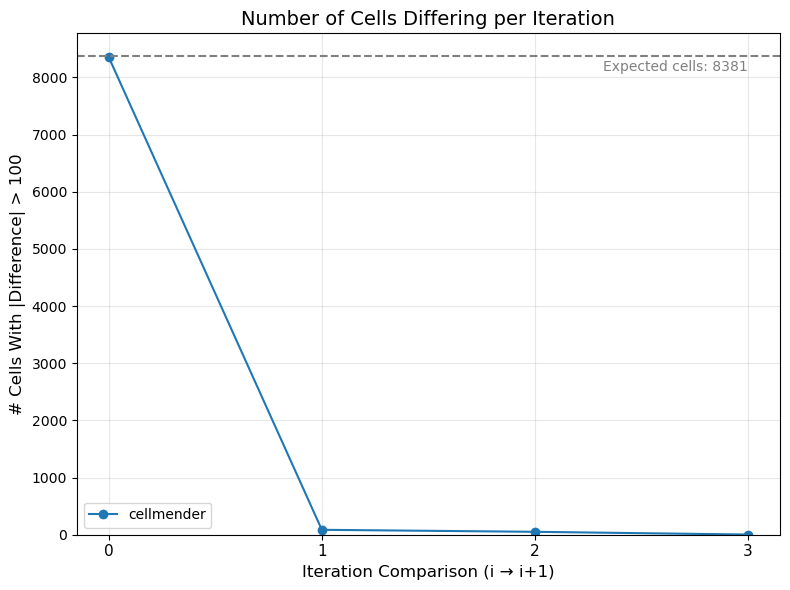

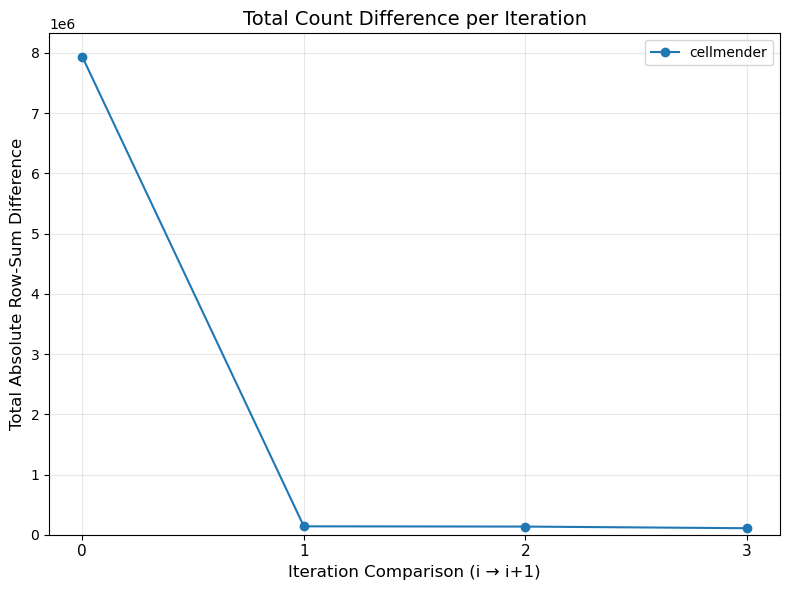

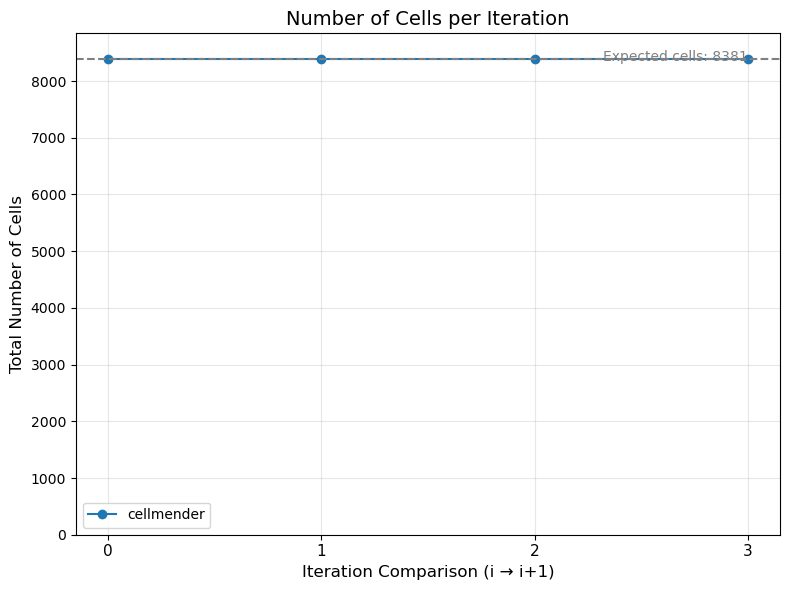

In [ ]:
diff_counts = cs_utils.plot_iterative_difference_counts(adatas_dict, metric="cells", expected_cells=expected_cells, threshold=100, title="Number of Cells Differing per Iteration", out_path=os.path.join(out_dir, "diff_cells.png"))
diff_counts = cs_utils.plot_iterative_difference_counts(adatas_dict, metric="counts", title="Total Count Difference per Iteration", out_path=os.path.join(out_dir, "diff_counts.png"))
diff_counts = cs_utils.plot_iterative_difference_counts(adatas_dict, metric="number_of_cells", expected_cells=expected_cells, title="Number of Cells per Iteration", out_path=os.path.join(out_dir, "diff_number_of_cells.png"))

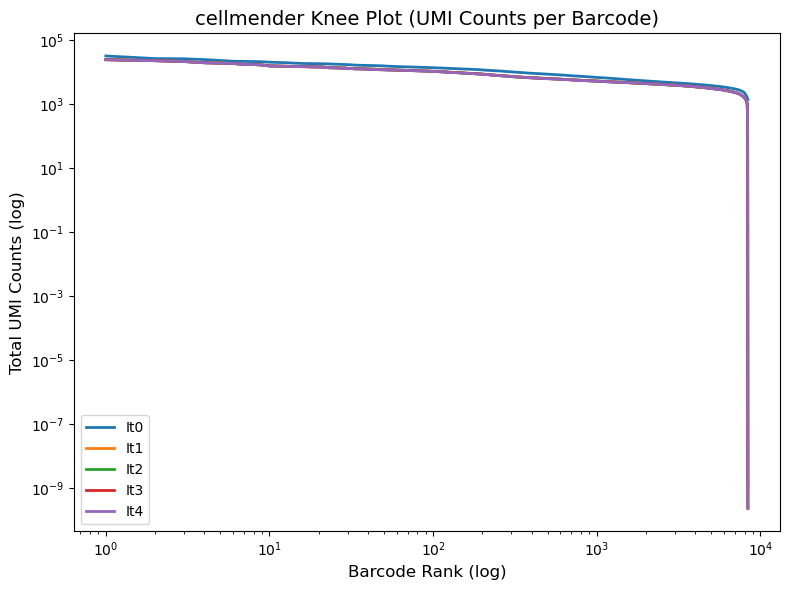

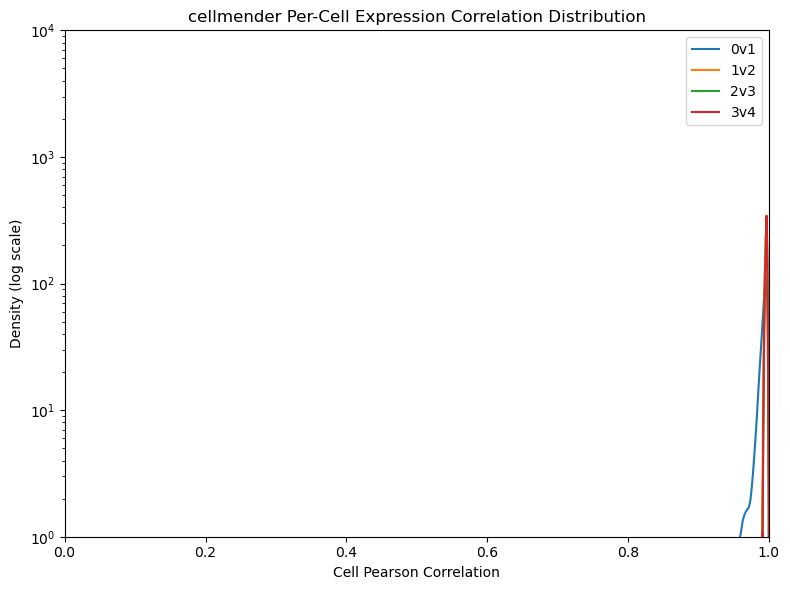

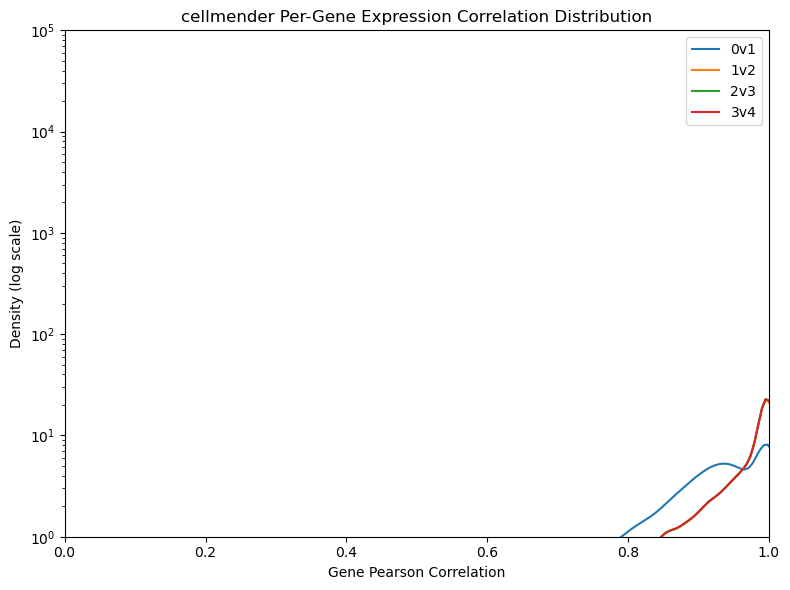

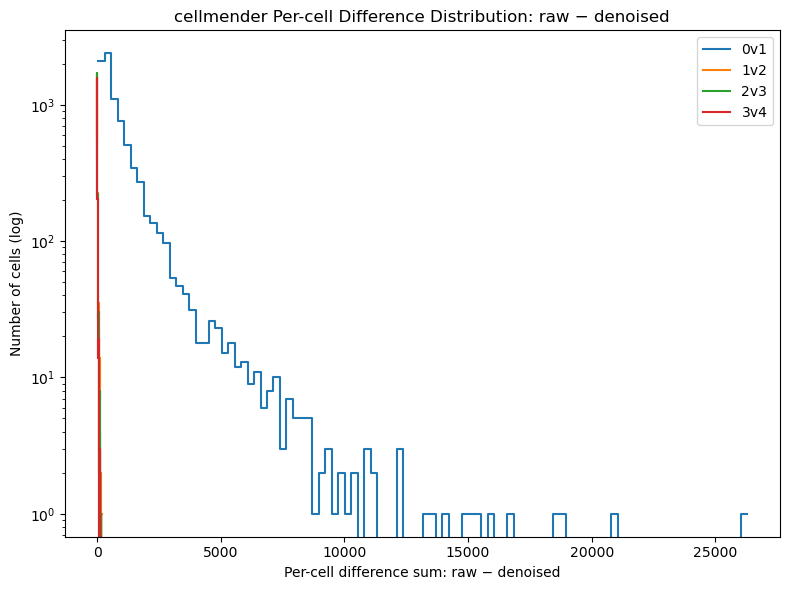

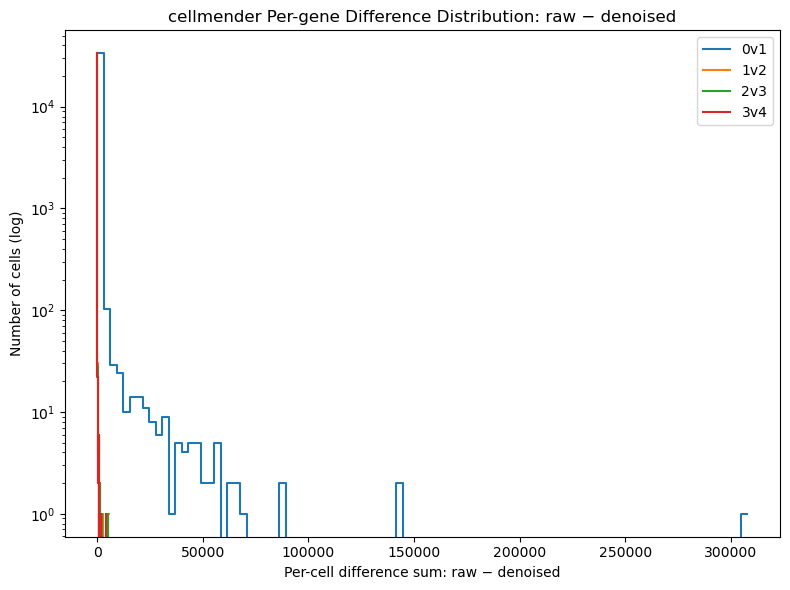

In [ ]:
labels_knee = [f"It{i}" for i in range(iterations+1)]
labels_histograms = [f"{i}v{i+1}" for i in range(iterations)]
for tool in tools:
    cs_utils.plot_knee_multi(adatas_dict[tool], labels=labels_knee, title=f"{tool} Knee Plot (UMI Counts per Barcode)", filter_empty=True, out_path=os.path.join(out_dir, f"{tool}_knee_plot_overlay.png"))
    
    cs_utils.plot_per_cell_correlation_multi(adatas_dict[tool][:-1], adatas_dict[tool][1:], labels=labels_histograms, plot_type="cell", title=f"{tool} Per-Cell Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_cell_correlation_overlay.png"))
    cs_utils.plot_per_cell_correlation_multi(adatas_dict[tool][:-1], adatas_dict[tool][1:], labels=labels_histograms, plot_type="gene", title=f"{tool} Per-Gene Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_gene_correlation_overlay.png"))
    
    cs_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_dict[tool][:-1], adata_denoised_list=adatas_dict[tool][1:], labels=labels_histograms, plot_type="cell", title=f"{tool} Per-cell Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_cell_absolute_difference_overlay.png"))
    cs_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_dict[tool][:-1], adata_denoised_list=adatas_dict[tool][1:], labels=labels_histograms, plot_type="gene", title=f"{tool} Per-gene Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_gene_absolute_difference_overlay.png"))

In [ ]:
# max_points = 10_000
# for i in range(1, iterations+1):
#     for tool in tools:
#         adatas_tool = adatas_dict[tool]
#         if len(adatas_tool) <= i:
#             continue
#         x_name = f"{tool} Iteration {i-1}" if i > 1 else "Raw expression"
#         y_name = f"{tool} Iteration {i}"

#         cs_utils.plot_matrix_scatterplot(adatas_tool[i-1], adatas_tool[i], scale="log", x_axis=x_name, y_axis=y_name, max_points=max_points, out_path=os.path.join(out_dir, f"{tool}_iteration{i}_expression_scatterplot_{max_points}points.png"), show=True)
#         cs_utils.plot_per_cell_correlation(adatas_tool[i-1], adatas_tool[i], title=f"Cell Pearson Correlation Histogram: {tool} Iteration {i}", out_path=os.path.join(out_dir, f"{tool}_iteration{i}_per_cell_correlation.png"))
#         cs_utils.plot_per_cell_difference(adatas_tool[i-1], adatas_tool[i], tool=tool, out_path=os.path.join(out_dir, f"{tool}_iteration{i}_per_cell_absolute_difference.png"))